**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

**Loading Dataset**

In [ ]:
df = pd.read_csv("/content/CC GENERAL.csv")
print(df.head())
print(df.isnull().sum())

  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000             0.083333   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                    0.000000                          0.083333   
1                    0.000000       

**Preprocessing and Feature Engineering**

In [ ]:
df.drop('CUST_ID', axis=1, inplace=True)
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean(), inplace=True)
print(df.isnull().sum().sum())

0


/tmp/ipython-input-3111172452.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
/tmp/ipython-input-3111172452.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

**Determine No. of Clusters**

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

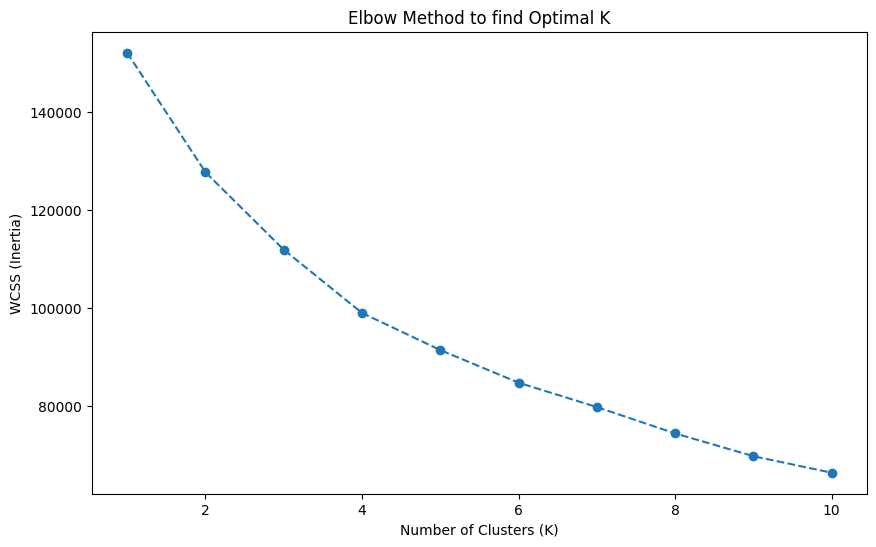

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

**Build K-Means Model**

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)
df['Cluster_Label'] = cluster_labels

**Analyzing the clusters**

In [ ]:
cluster_analysis = df.groupby('Cluster_Label').mean()
print("\nCluster Analysis (Mean values per cluster):")
print(cluster_analysis)


Cluster Analysis (Mean values per cluster):
                   BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster_Label                                                                  
0              2182.352833           0.981702  4187.017796       2663.995153   
1               807.722510           0.834577   496.062522        247.273214   
2              4023.788865           0.959193   389.051448        252.333261   

               INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster_Label                                                              
0                         1523.493231    449.753140             0.948175   
1                          249.110368    338.996760             0.460353   
2                          136.797412   3917.254973             0.233899   

               ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster_Label                                                                 
0              

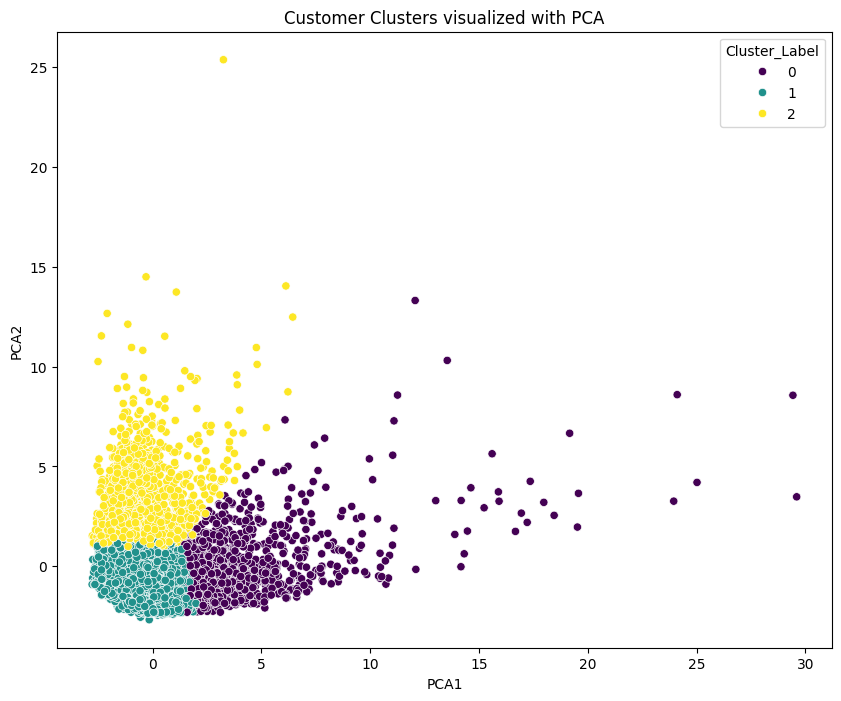

In [ ]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_data)
df['PCA1'] = pca_features[:, 0]
df['PCA2'] = pca_features[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Label', data=df, palette='viridis')
plt.title('Customer Clusters visualized with PCA')
plt.show()

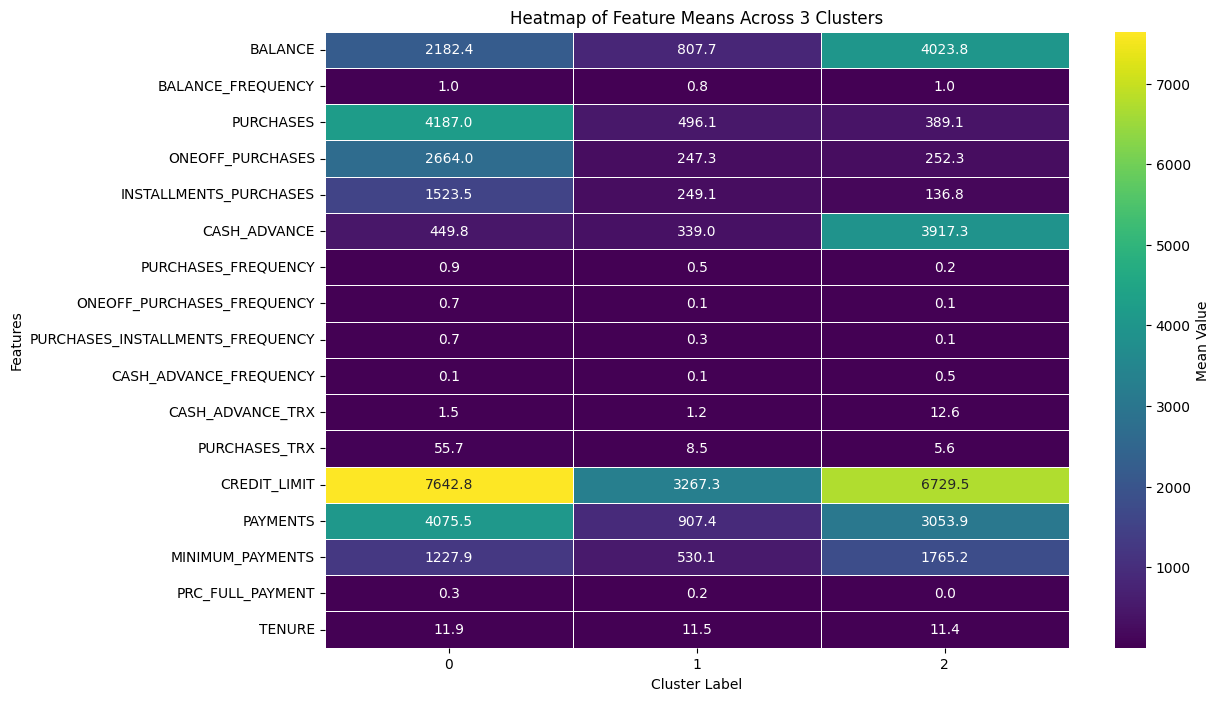

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_analysis.transpose(),
            cmap='viridis',
            annot=True,
            fmt=".1f",
            linewidths=.5,
            cbar_kws={'label': 'Mean Value'})

plt.title(f'Heatmap of Feature Means Across {optimal_k} Clusters')
plt.xlabel('Cluster Label')
plt.ylabel('Features')
plt.show()